# PIP-Based Trend Identification

Parallel implementation of trend detection using Perceptually Important Points (PIP).
Direct comparison with the original scoring-based algorithm.

In [1]:
# ── Data source ────────────────────────────────────────────────────────────
DATA_SOURCE      = "binance"   # "binance" or "local"
BINANCE_SYMBOL   = "BTCUSDT"
BINANCE_INTERVAL = "1h"
SYMBOL_LABEL = BINANCE_SYMBOL
TIMEFRAMES_TO_PLOT = ["15m", "1h", "4h"]

# ── PIP parameters ─────────────────────────────────────────────────────────
# n_pips: number of perceptually important points for global structure.
# Higher = more legs detected, lower = smoother/fewer legs. Start: 11.
N_PIPS = 11

# dist_measure: how geometric significance is measured.
# "perpendicular" is most accurate. "vertical" is fastest.
DIST_MEASURE = "perpendicular"

# n_pips_internal: PIP count for internal structure inside each impulse.
# Defaults to half of N_PIPS if set to None.
N_PIPS_INTERNAL = None

# ── EMA crossover markers (Note: filter_crossovers_in_impulses not yet implemented) ──
SHOW_EMA_CROSSOVERS = False

In [2]:
# -- Imports ------------------------------------------------------------------
import sys
from pathlib import Path
import yaml
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import asyncio

# Ensure repository root is importable when notebook runs from notebook/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.adapters.local_data import load_ohlc_from_csv as load_csv
from src.adapters.binance_data import fetch_binance_ohlc, fetch_binance_ohlc_sync
from src.core.trend_id import identify_trend, compute_internal_structure
from src.core.trend_id_pip import identify_trend_pip

In [3]:
# ── Data Loading ───────────────────────────────────────────────────────────

if DATA_SOURCE == "binance":
    print(f"Fetching {SYMBOL_LABEL} {BINANCE_INTERVAL} from Binance...")
    try:
        candles = fetch_binance_ohlc_sync(BINANCE_SYMBOL, BINANCE_INTERVAL)
        print(f"✓ Loaded {len(candles)} candles")
        if candles:
            print(f"  Date range: {candles[0].timestamp} to {candles[-1].timestamp}")
    except Exception as e:
        print(f"✗ Binance fetch failed: {e}")
        candles = []
else:  # local
    csv_path = Path("data/raw/ohlc.csv")
    if csv_path.exists():
        candles = load_csv(str(csv_path))
        print(f"✓ Loaded {len(candles)} candles from {csv_path}")
        if candles:
            print(f"  Date range: {candles[0].timestamp} to {candles[-1].timestamp}")
    else:
        print(f"✗ File not found: {csv_path}")
        candles = []

Fetching BTCUSDT 1h from Binance...
✓ Loaded 3000 candles
  Date range: 2025-11-10 00:00:00+00:00 to 2026-03-14 23:00:00+00:00


In [4]:
# ── Plotting Helper ────────────────────────────────────────────────────────

def draw_trend_chart_pip(candles, result, title, use_datetime_axis=False, figsize=(28, 8)):
    """Draw trend chart with PIP legs (adapted from notebook 08)."""
    display = candles
    fig, ax = plt.subplots(figsize=figsize)

    x_values = [c.timestamp for c in display] if use_datetime_axis else list(range(len(display)))
    prices = [c.close for c in display]
    ax.plot(x_values, prices, color='black', alpha=0.5, linewidth=1)

    def x_at(index):
        return display[index].timestamp if use_datetime_axis else index

    # Outer legs (global structure)
    for leg in result["legs"]:
        start_idx = leg["start_index"]
        end_idx = leg["end_index"] if leg["end_index"] is not None else len(display) - 1
        start_x = x_at(start_idx)
        end_x = x_at(end_idx)
        start_y = leg["start_price"]
        end_y = leg["end_price"] if leg["end_price"] is not None else display[-1].close

        if result["trend"] == "down":
            color = "red" if leg["type"] == "impulse" else "green"
        else:
            color = "green" if leg["type"] == "impulse" else "red"

        if not leg["confirmed"]:
            ax.plot([start_x, end_x], [start_y, end_y], color='grey', linestyle='--', linewidth=2)
        else:
            ax.plot([start_x, end_x], [start_y, end_y], color=color, linewidth=3)
            ax.scatter(end_x, end_y, color=color, s=100, zorder=5)

    # Internal structure (relative indices must be offset by parent_start)
    for leg in result["legs"]:
        internal = leg.get("internal_structure")
        parent_start = leg["start_index"]
        parent_end = leg["end_index"]
        if internal is None or parent_end is None:
            continue

        for internal_leg in internal["legs"]:
            relative_start = internal_leg["start_index"]
            relative_end = (internal_leg["end_index"]
                            if internal_leg["end_index"] is not None
                            else parent_end - parent_start)
            # Offset relative indices back to global coordinate space
            start_idx = parent_start + relative_start
            end_idx = min(parent_start + relative_end, parent_end)

            start_x = x_at(start_idx)
            end_x = x_at(end_idx)
            start_y = internal_leg["start_price"]
            end_y = (internal_leg["end_price"]
                     if internal_leg["end_price"] is not None
                     else display[end_idx].close)

            ax.plot([start_x, end_x], [start_y, end_y], color='black', linestyle='--', linewidth=2)

    # X-axis formatting
    if use_datetime_axis:
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    else:
        tick_step = max(1, len(display) // 20)
        tick_pos = list(range(0, len(display), tick_step))
        tick_lbl = [display[i].timestamp.strftime("%b %d\n%H:%M") for i in tick_pos]
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, fontsize=7, rotation=45)

    ax.set_title(f"{title} | Trend: {result['trend']} | {len(result['legs'])} legs | Phase: {result['current_phase']}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Fetching BTCUSDT 15M...
Candles: 3000 | Date: 2026-02-11 18:00:00+00:00 to 2026-03-14 23:45:00+00:00
Trend: up | Legs: 10 | Phase: retracement


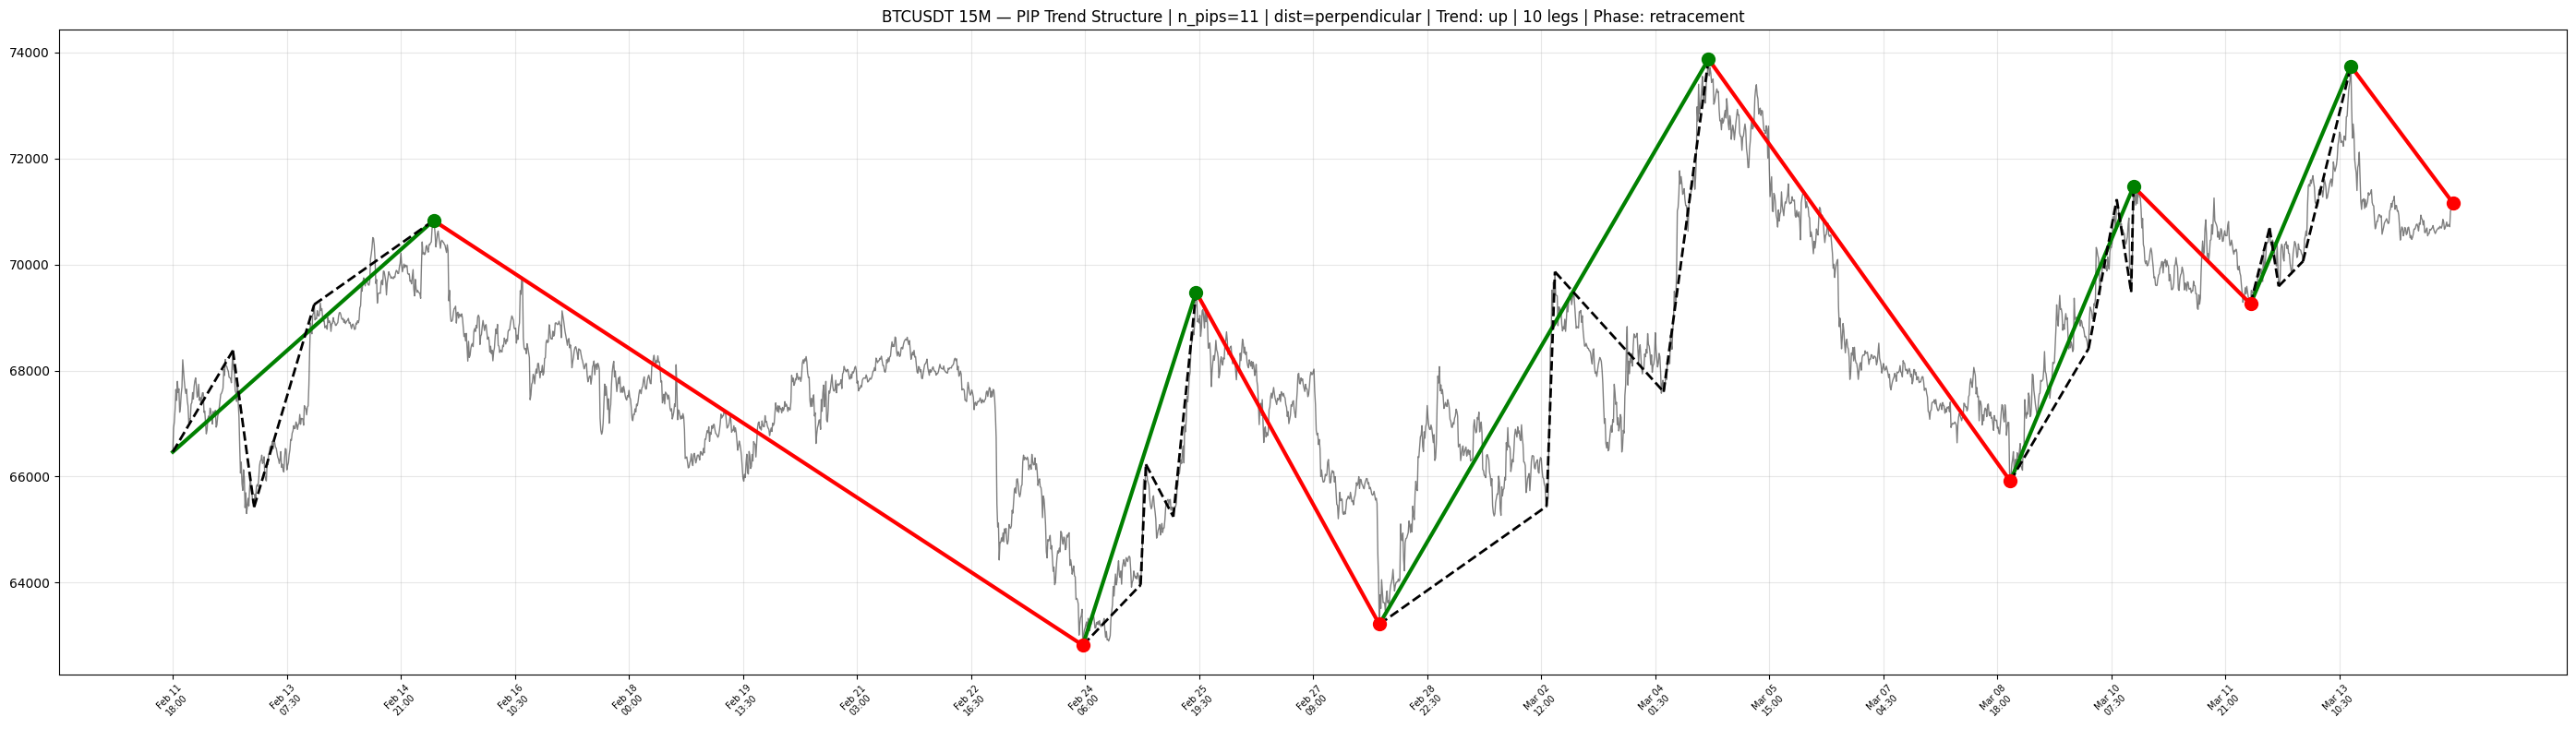


Fetching BTCUSDT 1H...
Candles: 3000 | Date: 2025-11-10 00:00:00+00:00 to 2026-03-14 23:00:00+00:00
Trend: down | Legs: 10 | Phase: retracement


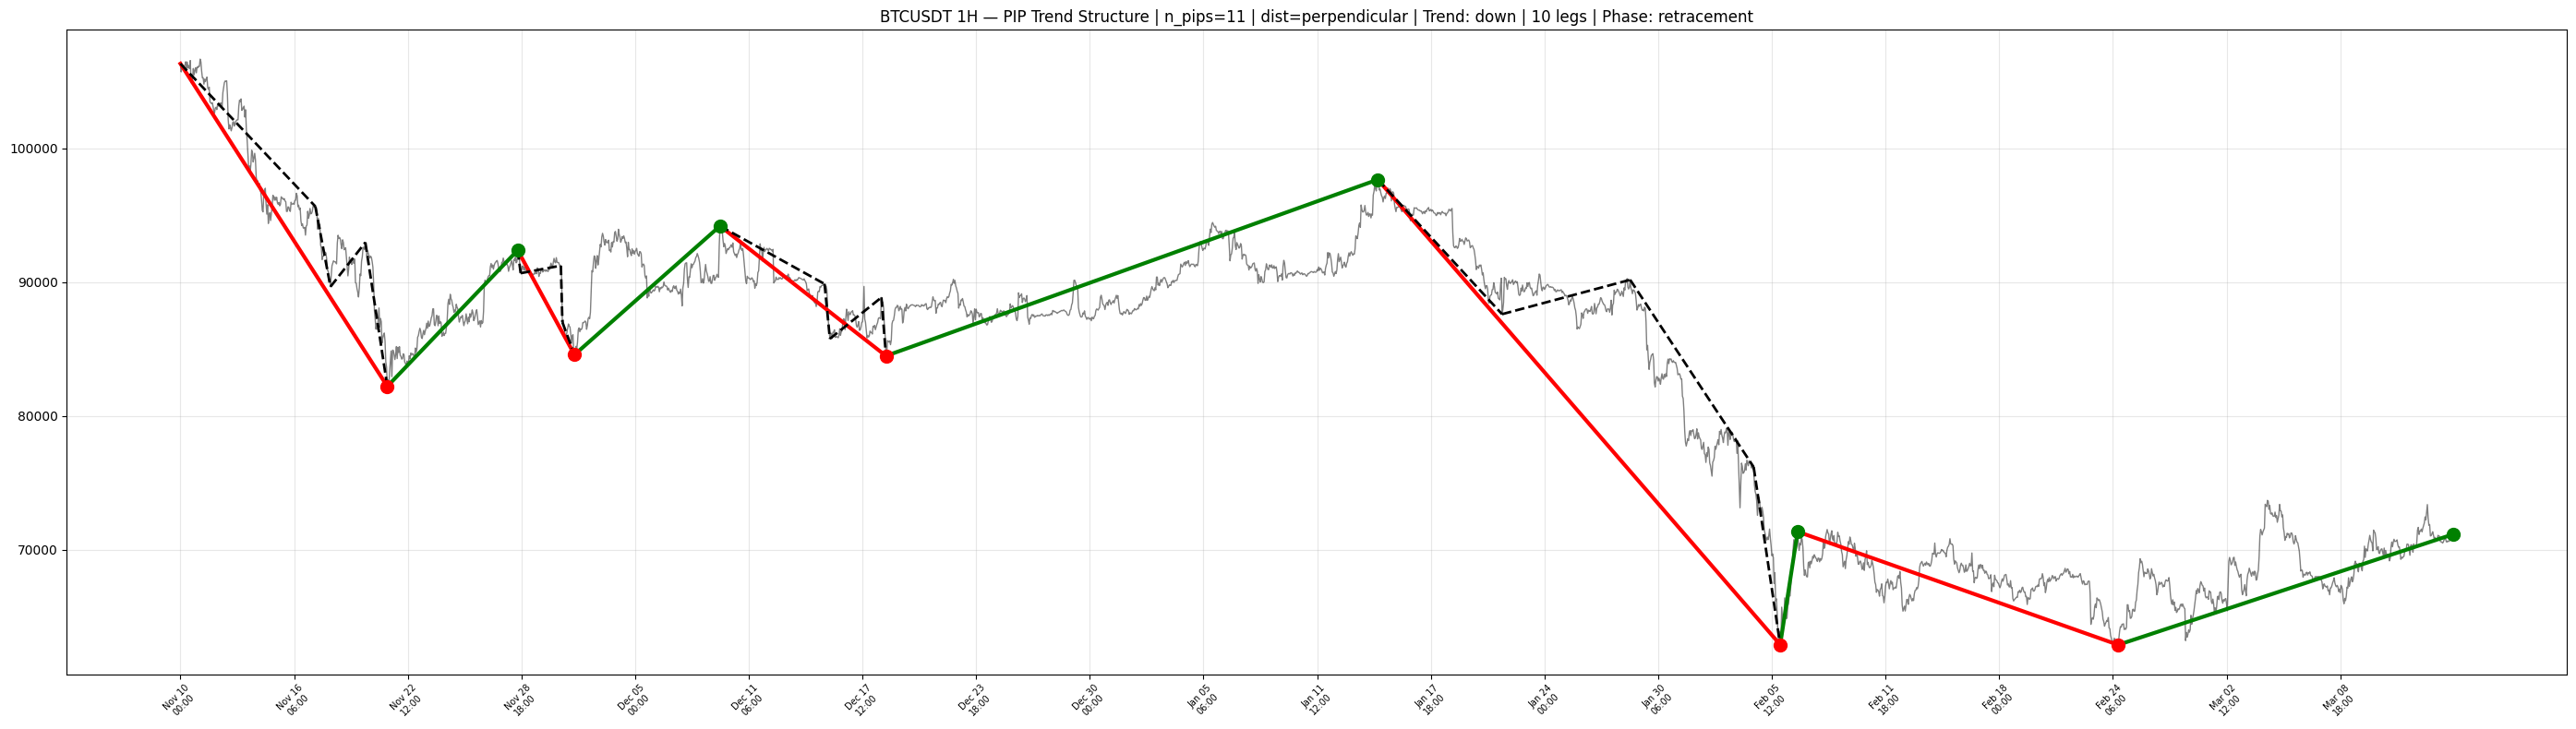


Fetching BTCUSDT 4H...
Candles: 3000 | Date: 2024-10-31 00:00:00+00:00 to 2026-03-14 20:00:00+00:00
Trend: range | Legs: 10 | Phase: retracement


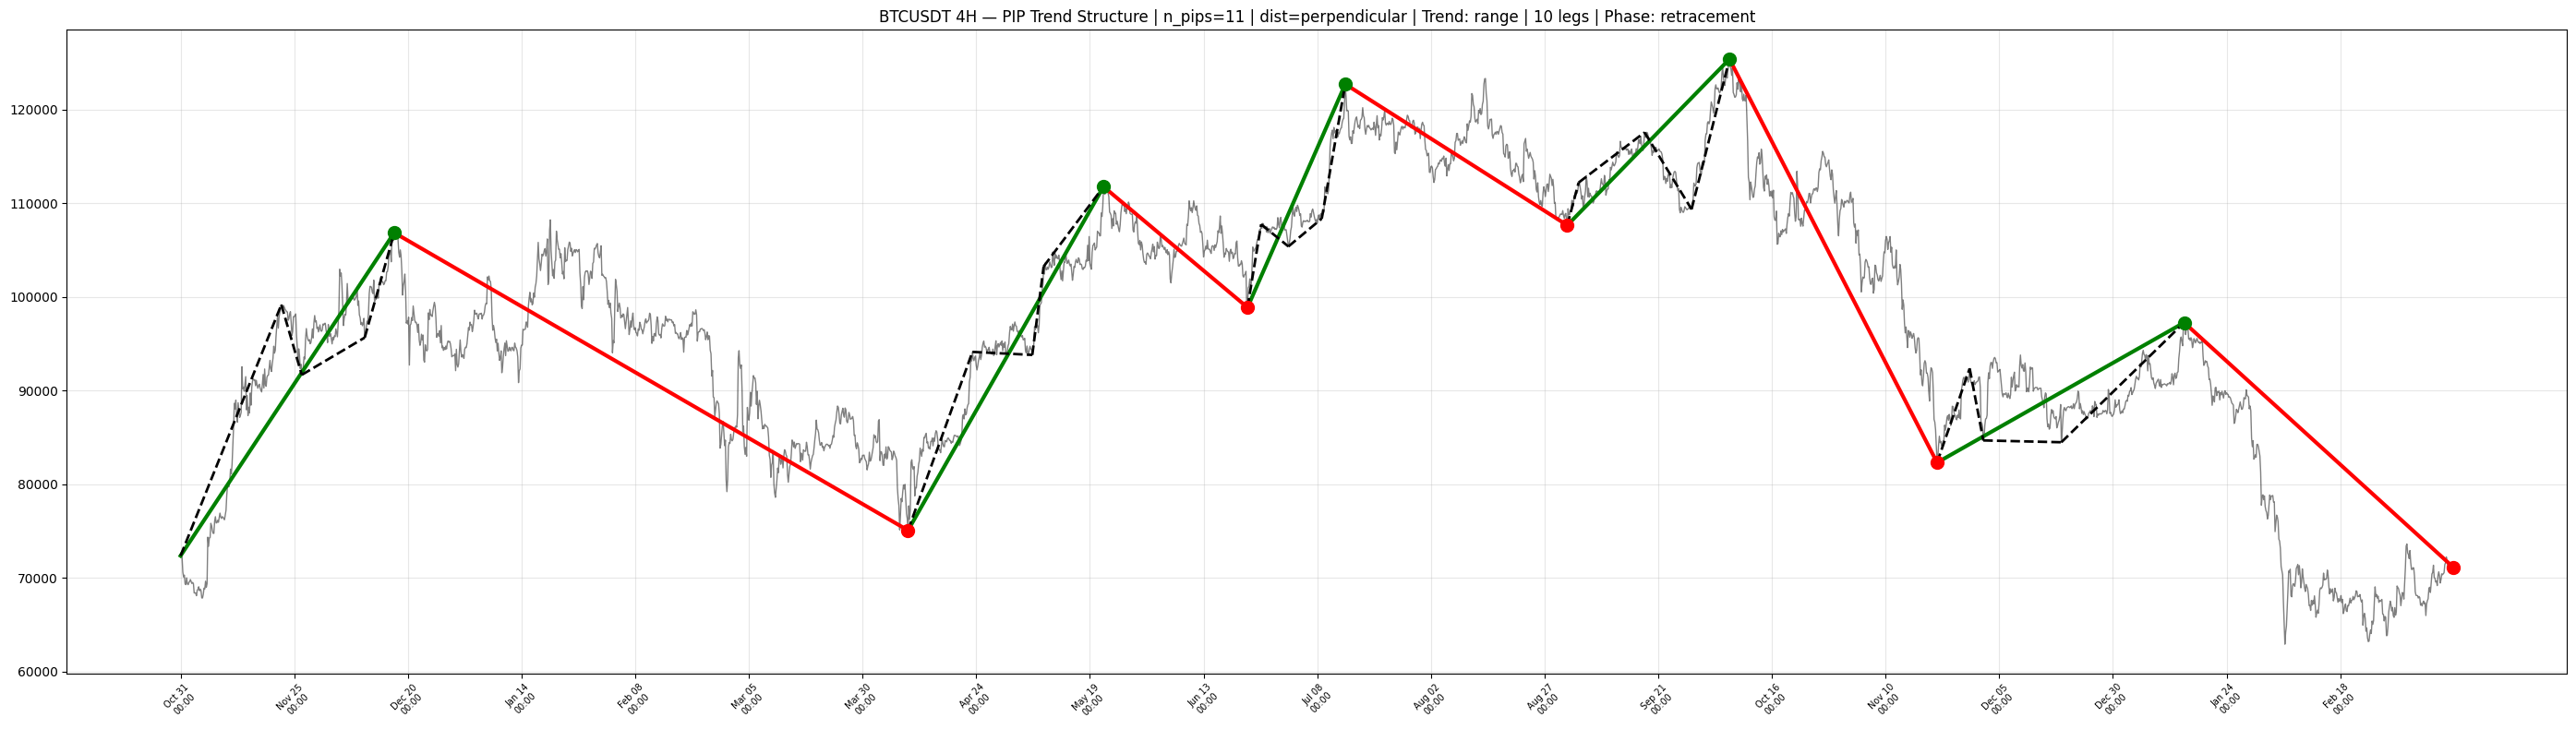

In [5]:
# ── Multi-Timeframe Loop ───────────────────────────────────────────────────

if not candles or len(candles) < 5:
    print("Not enough candles to analyze.")
else:
    for tf in TIMEFRAMES_TO_PLOT:
        print(f"\n{'='*80}")
        print(f"Fetching {SYMBOL_LABEL} {tf.upper()}...")
        print(f"{'='*80}")

        try:
            tf_candles = fetch_binance_ohlc_sync(BINANCE_SYMBOL, tf)
            if not tf_candles:
                print(f"No data for {tf}")
                continue

            # Identify trend using PIP method
            result = identify_trend_pip(
                tf_candles,
                n_pips=N_PIPS,
                dist_measure=DIST_MEASURE,
                n_pips_internal=N_PIPS_INTERNAL,
            )

            # Print summary
            print(f"Candles: {len(tf_candles)} | Date: {tf_candles[0].timestamp} to {tf_candles[-1].timestamp}")
            print(f"Trend: {result['trend']} | Legs: {len(result['legs'])} | Phase: {result['current_phase']}")

            # Plot
            title = f"{SYMBOL_LABEL} {tf.upper()} — PIP Trend Structure | n_pips={N_PIPS} | dist={DIST_MEASURE}"
            draw_trend_chart_pip(tf_candles, result, title, use_datetime_axis=False)

        except Exception as e:
            print(f"Error processing {tf}: {e}")


Side-by-Side Comparison: BTCUSDT 1H



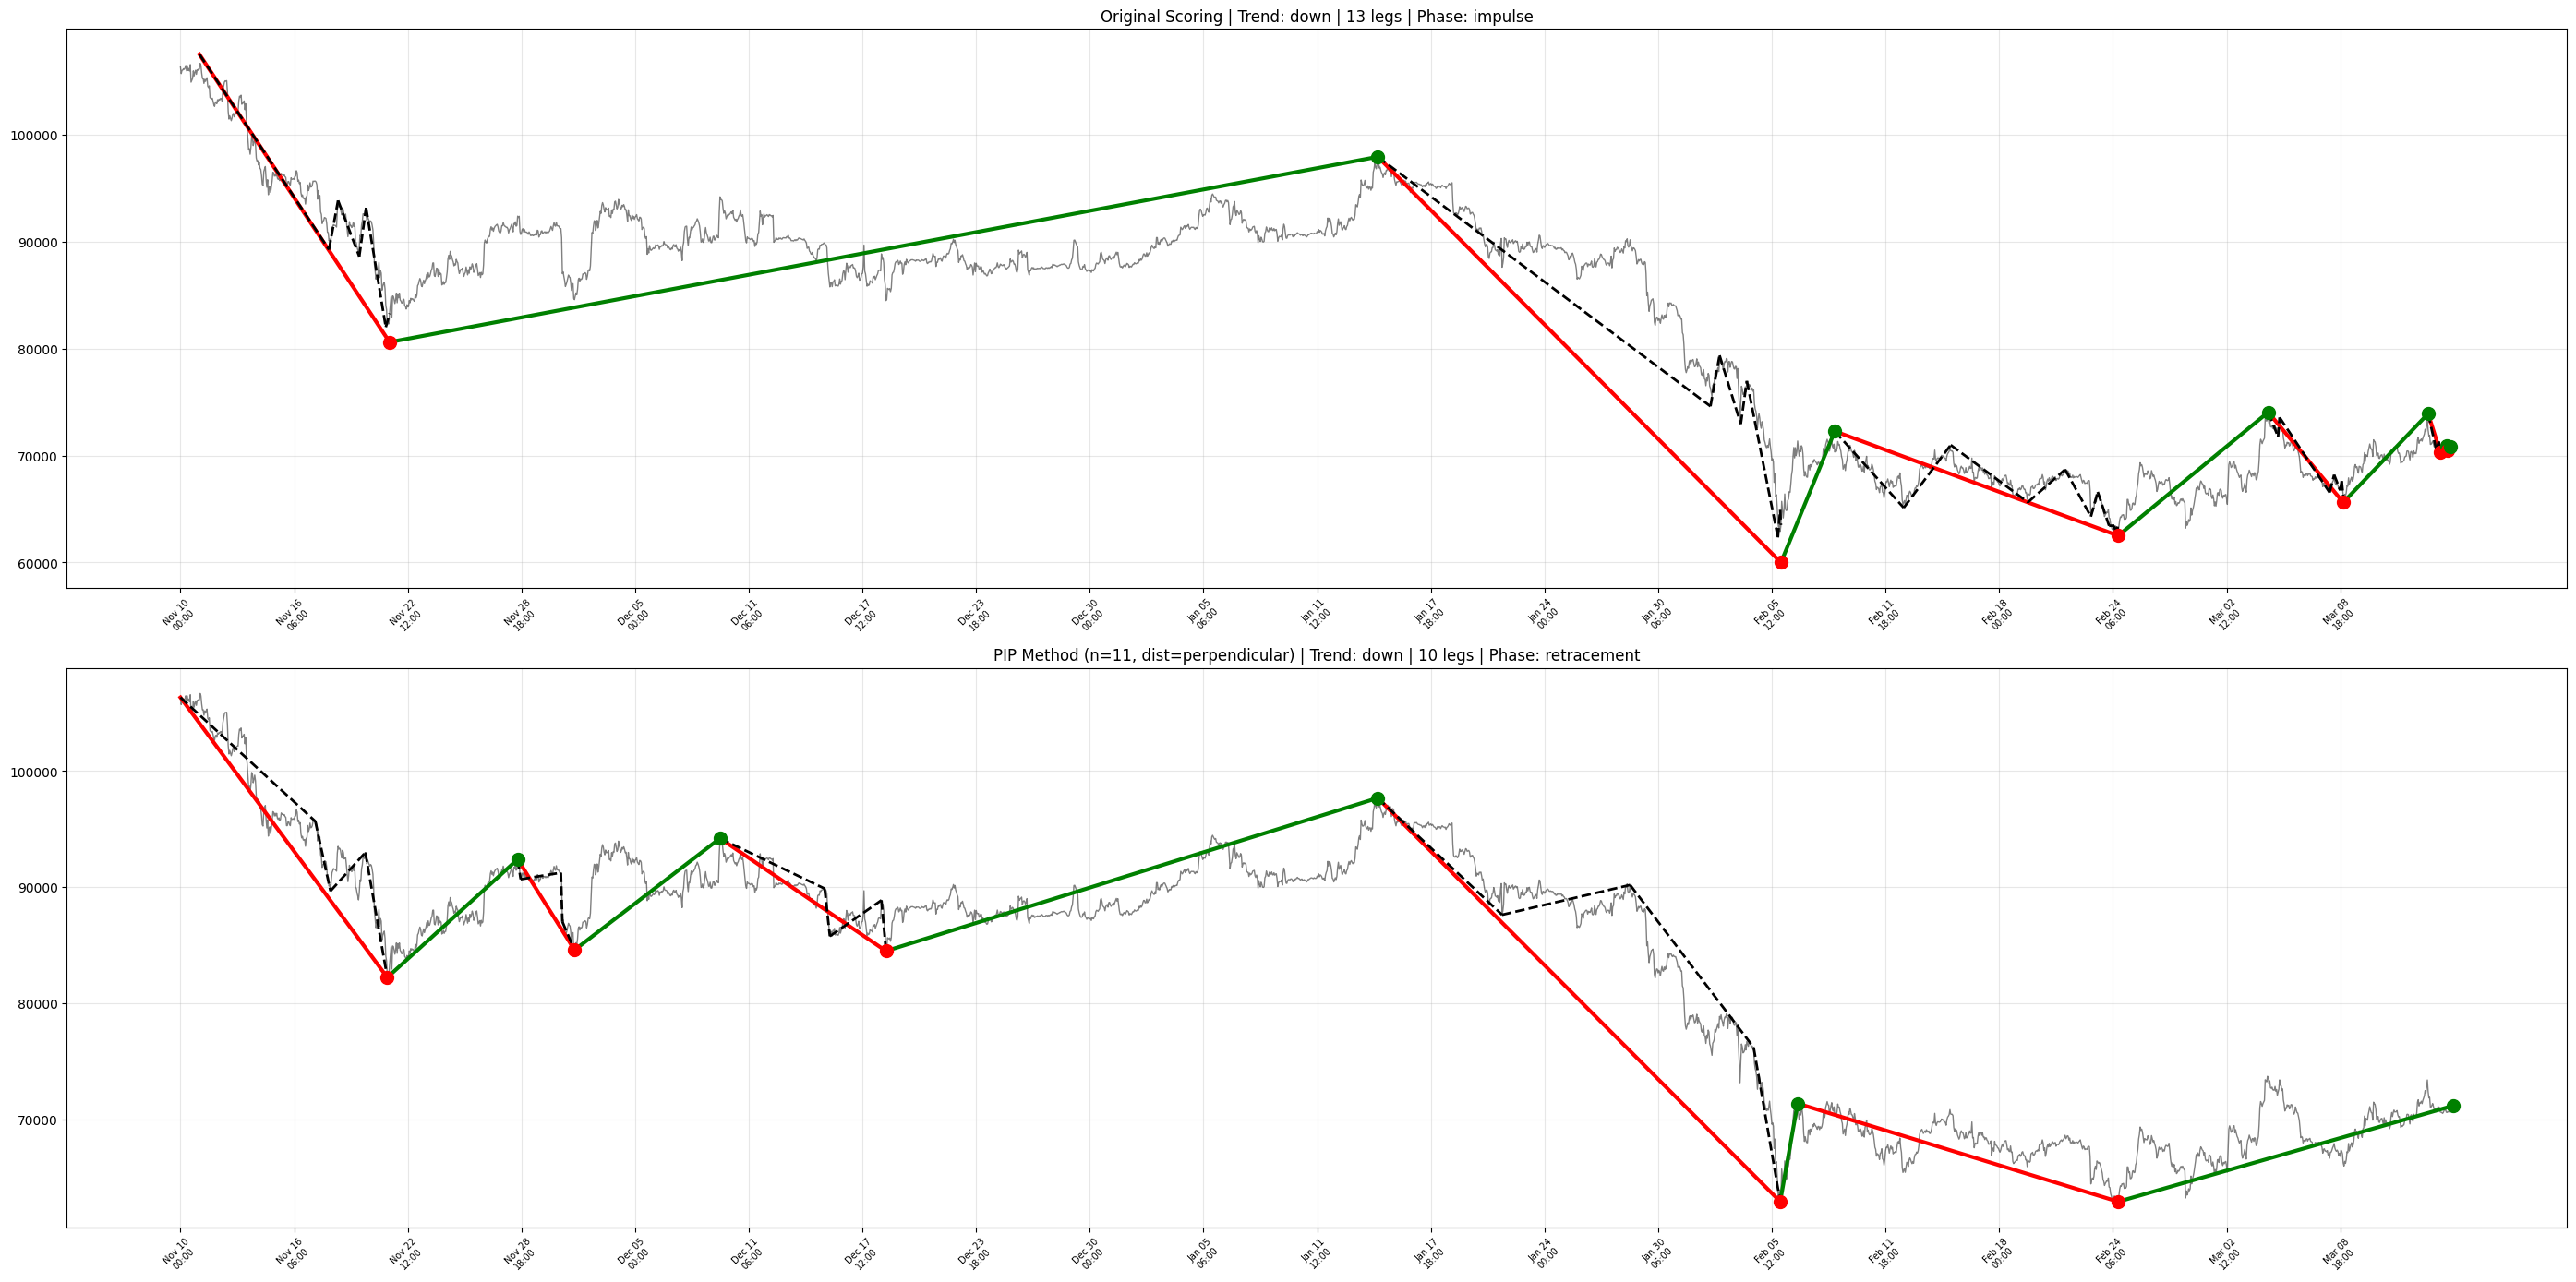

In [6]:
# ── Side-by-Side Comparison ───────────────────────────────────────────────

if not candles or len(candles) < 5:
    print("Not enough candles for comparison.")
else:
    print(f"\n{'='*80}")
    print(f"Side-by-Side Comparison: {BINANCE_SYMBOL} {BINANCE_INTERVAL.upper()}")
    print(f"{'='*80}\n")

    # Run both algorithms
    original_result = identify_trend(candles, min_swing_candles=1)
    compute_internal_structure(candles, original_result["legs"], min_swing_candles=1)

    pip_result = identify_trend_pip(
        candles,
        n_pips=N_PIPS,
        dist_measure=DIST_MEASURE,
        n_pips_internal=N_PIPS_INTERNAL,
    )

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 14))

    # Helper function to plot on given axis
    def plot_on_axis(ax, candles, result, title, is_top=True):
        display = candles
        x_values = list(range(len(display)))
        prices = [c.close for c in display]
        ax.plot(x_values, prices, color='black', alpha=0.5, linewidth=1)

        # Outer legs
        for leg in result["legs"]:
            start_idx = leg["start_index"]
            end_idx = leg["end_index"] if leg["end_index"] is not None else len(display) - 1
            start_x = start_idx
            end_x = end_idx
            start_y = leg["start_price"]
            end_y = leg["end_price"] if leg["end_price"] is not None else display[-1].close

            if result["trend"] == "down":
                color = "red" if leg["type"] == "impulse" else "green"
            else:
                color = "green" if leg["type"] == "impulse" else "red"

            if not leg["confirmed"]:
                ax.plot([start_x, end_x], [start_y, end_y], color='grey', linestyle='--', linewidth=2)
            else:
                ax.plot([start_x, end_x], [start_y, end_y], color=color, linewidth=3)
                ax.scatter(end_x, end_y, color=color, s=100, zorder=5)

        # Internal structure
        for leg in result["legs"]:
            internal = leg.get("internal_structure")
            parent_start = leg["start_index"]
            parent_end = leg["end_index"]
            if internal is None or parent_end is None:
                continue

            for internal_leg in internal["legs"]:
                relative_start = internal_leg["start_index"]
                relative_end = (internal_leg["end_index"]
                                if internal_leg["end_index"] is not None
                                else parent_end - parent_start)
                start_idx = parent_start + relative_start
                end_idx = min(parent_start + relative_end, parent_end)

                start_x = start_idx
                end_x = end_idx
                start_y = internal_leg["start_price"]
                end_y = (internal_leg["end_price"]
                         if internal_leg["end_price"] is not None
                         else display[end_idx].close)

                ax.plot([start_x, end_x], [start_y, end_y], color='black', linestyle='--', linewidth=2)

        # X-axis
        tick_step = max(1, len(display) // 20)
        tick_pos = list(range(0, len(display), tick_step))
        tick_lbl = [display[i].timestamp.strftime("%b %d\n%H:%M") for i in tick_pos]
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, fontsize=7, rotation=45)

        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    # Plot both
    plot_on_axis(ax1, candles, original_result,
                 f"Original Scoring | Trend: {original_result['trend']} | {len(original_result['legs'])} legs | Phase: {original_result['current_phase']}")
    plot_on_axis(ax2, candles, pip_result,
                 f"PIP Method (n={N_PIPS}, dist={DIST_MEASURE}) | Trend: {pip_result['trend']} | {len(pip_result['legs'])} legs | Phase: {pip_result['current_phase']}")

    plt.tight_layout()
    plt.show()